# Parkinson's Disease Progression Prediction
Using the UCI Parkinsons Telemonitoring Dataset to predict symptom severity (UPDRS scores).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import io
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Loading the dataset directly from UCI Repository
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/parkinsons/telemonitoring/parkinsons_updrs.data'
s = requests.get(url).content
df = pd.read_csv(io.StringIO(s.decode('utf-8')))

print("Dataset Shape:", df.shape)
display(df.head())
print(df.info())

Dataset Shape: (5875, 22)


,subject#,age,sex,test_time,motor_UPDRS,total_UPDRS,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,...,Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE
0,1,72,0,5.6431,28.199,34.398,0.00662,0.000034,0.00401,0.00317,...,0.230,0.01438,0.01309,0.01662,0.04314,0.014290,21.640,0.41888,0.54842,0.16006
1,1,72,0,12.6660,28.447,34.894,0.00300,0.000017,0.00132,0.00150,...,0.179,0.00994,0.01072,0.01689,0.02982,0.011112,27.183,0.43493,0.56477,0.10810
2,1,72,0,19.6810,28.695,35.389,0.00481,0.000025,0.00205,0.00208,...,0.181,0.00734,0.00844,0.01458,0.02202,0.020220,23.047,0.46222,0.54405,0.21014
3,1,72,0,25.6470,28.905,35.810,0.00528,0.000027,0.00191,0.00264,...,0.327,0.01106,0.01265,0.01963,0.03317,0.027837,24.445,0.48730,0.57794,0.33277
4,1,72,0,33.6420,29.187,36.375,0.00335,0.000020,0.00093,0.00130,...,0.176,0.00679,0.00929,0.01819,0.02036,0.011625,26.126,0.47188,0.56122,0.19361


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5875 entries, 0 to 5874
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   subject#       5875 non-null   int64  
 1   age            5875 non-null   int64  
 2   sex            5875 non-null   int64  
 3   test_time      5875 non-null   float64
 4   motor_UPDRS    5875 non-null   float64
 5   total_UPDRS    5875 non-null   float64
 6   Jitter(%)      5875 non-null   float64
 7   Jitter(Abs)    5875 non-null   float64
 8   Jitter:RAP     5875 non-null   float64
 9   Jitter:PPQ5    5875 non-null   float64
 10  Jitter:DDP     5875 non-null   float64
 11  Shimmer        5875 non-null   float64
 12  Shimmer(dB)    5875 non-null   float64
 13  Shimmer:APQ3   5875 non-null   float64
 14  Shimmer:APQ5   5875 non-null   float64
 15  Shimmer:APQ11  5875 non-null   float64
 16  Shimmer:DDA    5875 non-null   float64
 17  NHR            5875 non-null   float64
 18  HNR     

,count,mean,std,min,25%,50%,75%,max
subject#,5875.0,21.494128,12.372279,1.000000,10.000000,22.000000,33.000000,42.000000
age,5875.0,64.804936,8.821524,36.000000,58.000000,65.000000,72.000000,85.000000
sex,5875.0,0.317787,0.465656,0.000000,0.000000,0.000000,1.000000,1.000000
test_time,5875.0,92.863722,53.445602,-4.262500,46.847500,91.523000,138.445000,215.490000
motor_UPDRS,5875.0,21.296229,8.129282,5.037700,15.000000,20.871000,27.596500,39.511000
total_UPDRS,5875.0,29.018942,10.700283,7.000000,21.371000,27.576000,36.399000,54.992000
Jitter(%),5875.0,0.006154,0.005624,0.000830,0.003580,0.004900,0.006800,0.099990
Jitter(Abs),5875.0,0.000044,0.000036,0.000002,0.000022,0.000035,0.000053,0.000446
Jitter:RAP,5875.0,0.002987,0.003124,0.000330,0.001580,0.002250,0.003290,0.057540
Jitter:PPQ5,5875.0,0.003277,0.003732,0.000430,0.001820,0.002490,0.003460,0.069560


Missing values:
 Series([], dtype: int64)


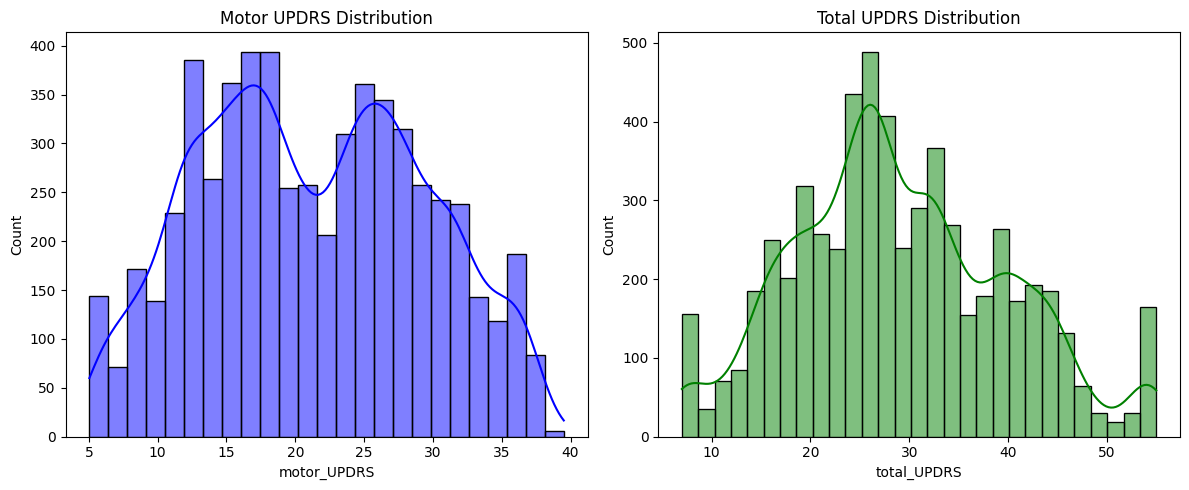

In [2]:
# Exploratory Data Analysis & Statistical Summary
stats = df.describe().T
display(stats)

# Checking for missing values
missing = df.isnull().sum()
print("Missing values:\n", missing[missing > 0] if not missing.empty else "No missing values")

# Target distribution
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['motor_UPDRS'], kde=True, color='blue')
plt.title('Motor UPDRS Distribution')

plt.subplot(1, 2, 2)
sns.histplot(df['total_UPDRS'], kde=True, color='green')
plt.title('Total UPDRS Distribution')
plt.tight_layout()
plt.show()

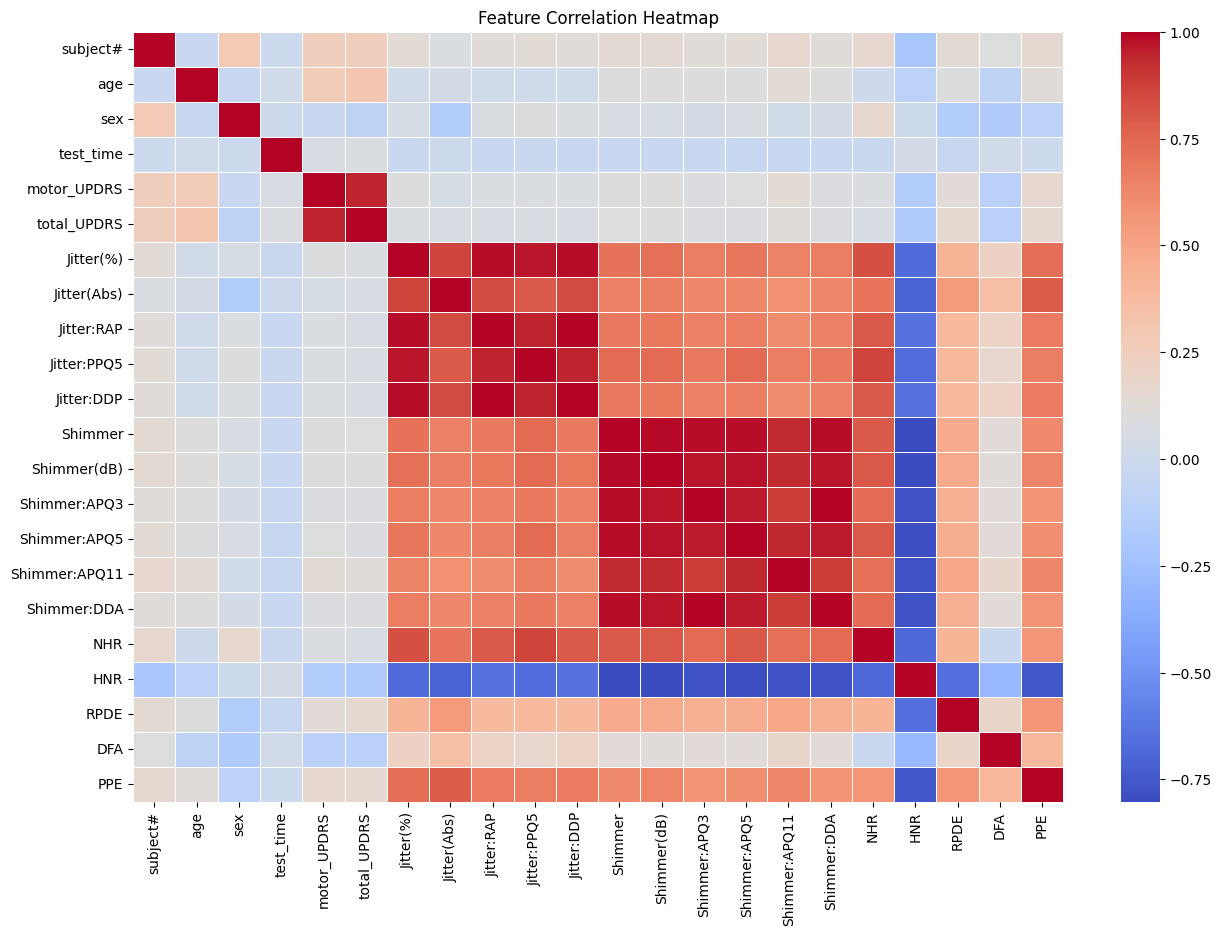

Correlation with Total UPDRS:
 total_UPDRS      1.000000
motor_UPDRS      0.947231
age              0.310290
subject#         0.253643
RPDE             0.156897
PPE              0.156195
Shimmer:APQ11    0.120838
Shimmer(dB)      0.098790
Shimmer          0.092141
Shimmer:APQ5     0.083467
Shimmer:DDA      0.079363
Shimmer:APQ3     0.079363
test_time        0.075263
Jitter(%)        0.074247
Jitter(Abs)      0.066927
Jitter:DDP       0.064027
Jitter:RAP       0.064015
Jitter:PPQ5      0.063352
NHR              0.060952
sex             -0.096559
DFA             -0.113475
HNR             -0.162117
Name: total_UPDRS, dtype: float64


In [3]:
# Correlation Analysis
plt.figure(figsize=(15, 10))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

# Identify highly correlated features with the target
top_corr = corr_matrix['total_UPDRS'].sort_values(ascending=False)
print("Correlation with Total UPDRS:\n", top_corr)

In [13]:
# Feature Engineering and Preprocessing

# Mapping for more descriptive column names
rename_map = {
    'Jitter(%)': 'Jitter_Percent',
    'Jitter(Abs)': 'Jitter_Absolute',
    'Jitter:RAP': 'Jitter_RAP',
    'Jitter:PPQ5': 'Jitter_PPQ5',
    'Jitter:DDP': 'Jitter_DDP',
    'Shimmer': 'Shimmer_Local',
    'Shimmer(dB)': 'Shimmer_dB',
    'Shimmer:APQ3': 'Shimmer_APQ3',
    'Shimmer:APQ5': 'Shimmer_APQ5',
    'Shimmer:APQ11': 'Shimmer_APQ11',
    'Shimmer:DDA': 'Shimmer_DDA',
    'NHR': 'Noise_to_Harmonics_Ratio',
    'HNR': 'Harmonics_to_Noise_Ratio',
    'RPDE': 'Recurrence_Period_Density_Entropy',
    'DFA': 'Detrended_Fluctuation_Analysis',
    'PPE': 'Pitch_Period_Entropy'
}

# Renaming the columns in the main dataframe
df_renamed = df.rename(columns=rename_map)

# Dropping subject ID for modeling
X = df_renamed.drop(['subject#', 'motor_UPDRS', 'total_UPDRS'], axis=1)
y_total = df_renamed['total_UPDRS']
y_motor = df_renamed['motor_UPDRS']

# Scaling features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_total, test_size=0.2, random_state=42)

print(f"New Feature Names: {list(X.columns)}")
print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

New Feature Names: ['age', 'sex', 'test_time', 'Jitter_Percent', 'Jitter_Absolute', 'Jitter_RAP', 'Jitter_PPQ5', 'Jitter_DDP', 'Shimmer_Local', 'Shimmer_dB', 'Shimmer_APQ3', 'Shimmer_APQ5', 'Shimmer_APQ11', 'Shimmer_DDA', 'Noise_to_Harmonics_Ratio', 'Harmonics_to_Noise_Ratio', 'Recurrence_Period_Density_Entropy', 'Detrended_Fluctuation_Analysis', 'Pitch_Period_Entropy']
Training set size: (4700, 19)
Testing set size: (1175, 19)


In [5]:
# Model Training: Gradient Boosting Regressor
gb_model = GradientBoostingRegressor(n_estimators=500, learning_rate=0.1, max_depth=5, random_state=42)
gb_model.fit(X_train, y_train)

# Predictions
y_pred = gb_model.predict(X_test)

# Evaluation Metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.4f}")
print(f"Root Mean Squared Error: {rmse:.4f}")
print(f"R2 Score: {r2:.4f}")

Mean Squared Error: 4.4403
Root Mean Squared Error: 2.1072
R2 Score: 0.9599


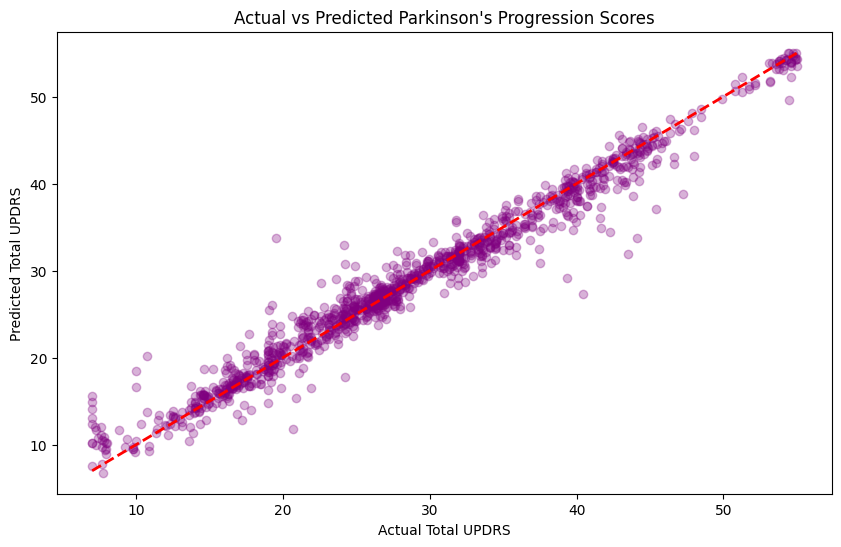

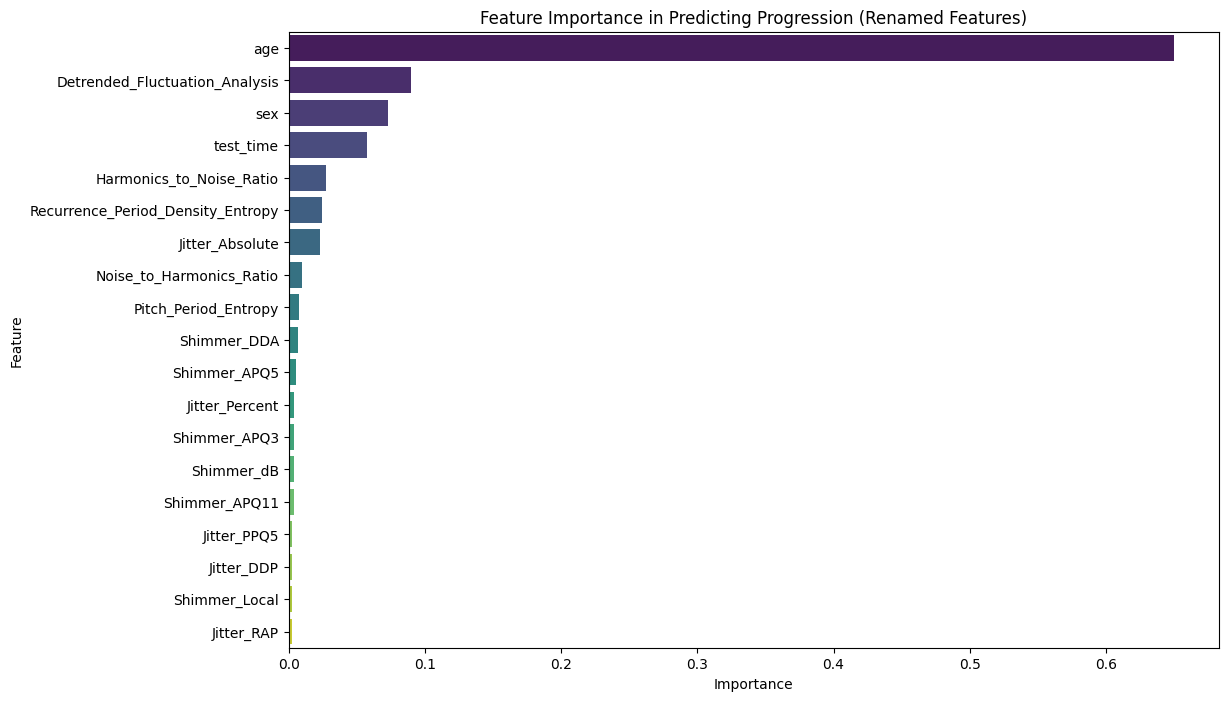

In [14]:
# Visualizing Model Performance with Renamed Features
plt.figure(figsize=(10, 6))
plt.scatter(y_test, final_pred, alpha=0.3, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.xlabel('Actual Total UPDRS')
plt.ylabel('Predicted Total UPDRS')
plt.title('Actual vs Predicted Parkinson\'s Progression Scores')
plt.show()

# Updated Feature Importance Analysis
feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': best_gb.feature_importances_})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance, hue='Feature', palette='viridis', legend=False)
plt.title('Feature Importance in Predicting Progression (Renamed Features)')
plt.show()

In [7]:
# Cross-Validation for Robustness
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(gb_model, X_scaled, y_total, cv=5, scoring='r2')
print(f"Cross-validated R2 scores: {cv_scores}")
print(f"Mean CV R2: {cv_scores.mean():.4f}")

Cross-validated R2 scores: [-1.76138759 -3.28305615  0.35514198 -1.44974471 -1.07665195]
Mean CV R2: -1.4431


In [8]:
from sklearn.model_selection import RandomizedSearchCV

# Defining the parameter grid for tuning
param_dist = {
    'n_estimators': [100, 300, 500, 1000],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6],
    'min_samples_split': [2, 5, 10],
    'subsample': [0.7, 0.8, 0.9, 1.0]
}

# Initialize RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

# Fit the tuner
random_search.fit(X_train, y_train)

print("Best Parameters Found:", random_search.best_params_)
print(f"Best Cross-Validation R2: {random_search.best_score_:.4f}")

# Update model with best estimator
best_gb = random_search.best_estimator_

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters Found: {'subsample': 0.7, 'n_estimators': 500, 'min_samples_split': 10, 'max_depth': 6, 'learning_rate': 0.1}
Best Cross-Validation R2: 0.9592


--- Final Optimized Model Metrics ---
MSE: 3.8291
RMSE: 1.9568
R2 Score: 0.9654


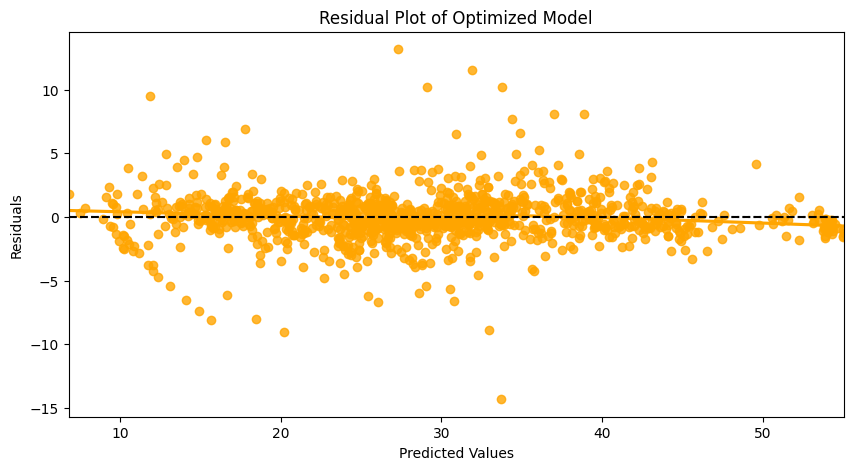

In [9]:
# Final Evaluation of the Optimized Model
final_pred = best_gb.predict(X_test)

final_mse = mean_squared_error(y_test, final_pred)
final_r2 = r2_score(y_test, final_pred)

print("--- Final Optimized Model Metrics ---")
print(f"MSE: {final_mse:.4f}")
print(f"RMSE: {np.sqrt(final_mse):.4f}")
print(f"R2 Score: {final_r2:.4f}")

# Comparison plot of Original vs Optimized (Residuals)
plt.figure(figsize=(10, 5))
sns.residplot(x=final_pred, y=y_test, lowess=True, color='orange')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot of Optimized Model')
plt.axhline(0, color='black', linestyle='--')
plt.show()

In [10]:
# Model Comparison: Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=300, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_mse = mean_squared_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("--- Random Forest Regressor Metrics ---")
print(f"MSE: {rf_mse:.4f}")
print(f"RMSE: {np.sqrt(rf_mse):.4f}")
print(f"R2 Score: {rf_r2:.4f}")

--- Random Forest Regressor Metrics ---
MSE: 2.4947
RMSE: 1.5795
R2 Score: 0.9775


Mean Absolute Error by Severity Group:
Severity
Moderate    1.146277
Severe      1.416186
Mild        1.440768
Name: Error, dtype: float64


/tmp/ipykernel_10555/464093725.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Severity', y='Error', data=error_df, palette='Set2')


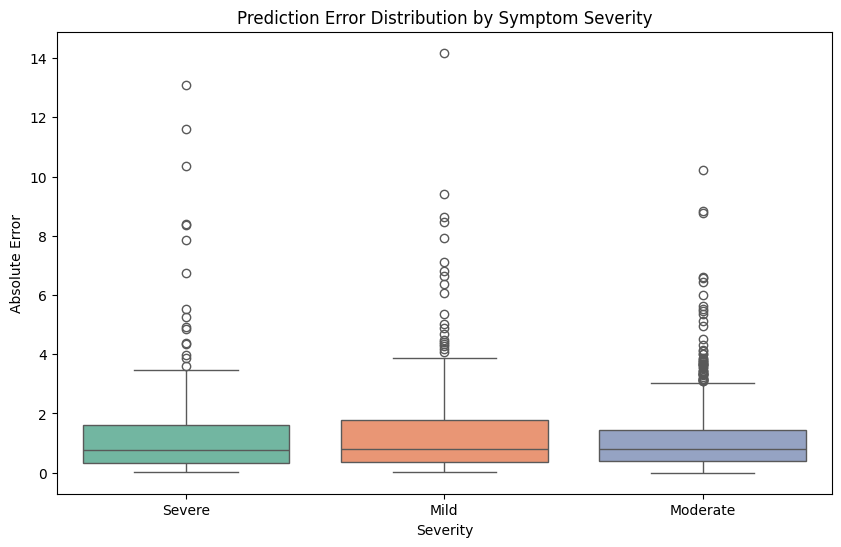

In [11]:
# Deep Error Analysis
error_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': final_pred,
    'Error': np.abs(y_test - final_pred)
})

# Analyzing error by UPDRS range
def categorize_severity(score):
    if score < 20: return 'Mild'
    elif score < 40: return 'Moderate'
    else: return 'Severe'

error_df['Severity'] = error_df['Actual'].apply(categorize_severity)

severity_error = error_df.groupby('Severity')['Error'].mean().sort_values()
print("Mean Absolute Error by Severity Group:")
print(severity_error)

plt.figure(figsize=(10, 6))
sns.boxplot(x='Severity', y='Error', data=error_df, palette='Set2')
plt.title('Prediction Error Distribution by Symptom Severity')
plt.ylabel('Absolute Error')
plt.show()

In [15]:
# Final Model Serialization and Summary
import joblib
import json

model_filename = 'parkinsons_progression_model.pkl'
scaler_filename = 'feature_scaler.pkl'

joblib.dump(best_gb, model_filename)
joblib.dump(scaler, scaler_filename)

print(f"Model saved as {model_filename}")
print(f"Scaler saved as {scaler_filename}")

# Summary of the pipeline with updated names
def get_pipeline_summary():
    return {
        'rows_processed': len(df_renamed),
        'features_used': list(X.columns),
        'best_model': 'GradientBoostingRegressor (Tuned)',
        'final_r2': final_r2
    }

print("Pipeline Summary:")
print(json.dumps(get_pipeline_summary(), indent=4))

Model saved as parkinsons_progression_model.pkl
Scaler saved as feature_scaler.pkl
Pipeline Summary:
{
    "rows_processed": 5875,
    "features_used": [
        "age",
        "sex",
        "test_time",
        "Jitter_Percent",
        "Jitter_Absolute",
        "Jitter_RAP",
        "Jitter_PPQ5",
        "Jitter_DDP",
        "Shimmer_Local",
        "Shimmer_dB",
        "Shimmer_APQ3",
        "Shimmer_APQ5",
        "Shimmer_APQ11",
        "Shimmer_DDA",
        "Noise_to_Harmonics_Ratio",
        "Harmonics_to_Noise_Ratio",
        "Recurrence_Period_Density_Entropy",
        "Detrended_Fluctuation_Analysis",
        "Pitch_Period_Entropy"
    ],
    "best_model": "GradientBoostingRegressor (Tuned)",
    "final_r2": 0.965445517348342
}
